In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
retail = pd.read_csv('data.nosync/online_retail_II.zip',compression="zip")
retail.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [14]:
##### print("--- Structure ---")
print(retail.info())
print("--- Missing Value ---")
print(retail.isna().sum())
print("--- Overview ---")
print(retail.describe())

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 136.6 MB
None
--- Missing Value ---
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64
--- Overview ---
           Quantity         Price    Customer ID
count  1.067371e+06  1.067371e+06  824364.000000
mean   9.938898e+00  4.649388e+00   15324.638504
std    1.727058e+02

In [4]:
def cleaning(df):
    df_clean = df.copy()
    print(f"Rows before cleaning: {len(df)}")

    # 1. Droping duplicates rows
    df_clean.drop_duplicates(keep="last",inplace=True)
    
    # 2. Standardizing column name, time format
    df_clean.columns = df_clean.columns.str.strip().str.lower().str.replace(" ","_")
    df_clean.rename(columns={"price":"unit_price"},inplace=True)
    df_clean['invoicedate'] = pd.to_datetime(df_clean['invoicedate'],errors="coerce")
    
    # 3. Dropping missing customerid ,invalid rows
    df_clean = df_clean.dropna(subset=["customer_id"])
    df_clean=df_clean.loc[(df_clean["quantity"]>0) & (df_clean["unit_price"]>0),:].copy()

    # 4. Filling missing value in description columns
    df_clean["description"] = df_clean["description"].fillna("unknown")
    
    print(f"Rows After cleaning: {len(df_clean)}\nRows dropped: {(len(df)-len(df_clean))*100/len(df):.2f}%")
    return df_clean.reset_index(drop=True)

retail_clean = cleaning(retail)

Rows before cleaning: 1067371
Rows After cleaning: 779425
Rows dropped: 26.98%


- I removed exact duplicate rows assuming system-level duplication. If further analysis shows repeated transaction lines, I would aggregate instead of dropping

## Cohort Analysis: Time

In [5]:
retail_clean['invoice_month']=retail_clean['invoicedate'].dt.to_period("M").dt.to_timestamp()
retail_clean['cohort_month']=retail_clean.groupby("customer_id")["invoice_month"].transform("min")

In [6]:
# Cohort based on month
retail_clean["cohort_index"]= (retail_clean['invoice_month'].dt.year-retail_clean['cohort_month'].dt.year)*12 +\
                              (retail_clean['invoice_month'].dt.month-retail_clean['cohort_month'].dt.month)

## Counting monthly active customers in cohorts

In [7]:
#long format
retail_clean.groupby(["cohort_month","cohort_index"])["customer_id"].nunique().reset_index(name="value").head()

,cohort_month,cohort_index,value
0,2009-12-01,0,955
1,2009-12-01,1,337
2,2009-12-01,2,319
3,2009-12-01,3,406
4,2009-12-01,4,363


In [8]:
#wider format
cohots_counts=retail_clean.pivot_table(values="customer_id",
                                       index="cohort_month",
                                       columns='cohort_index',
                                       aggfunc='nunique',
                                       fill_value=0)
cohots_counts.head()

cohort_index,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
cohort_month,,,,,,,,,,,,,,,,,,,,,
2009-12-01,955,337,319,406,363,343,360,327,321,346,...,289,251,289,270,248,244,301,291,389,188
2010-01-01,383,79,119,117,101,115,99,88,107,122,...,58,90,76,71,75,93,74,94,22,0
2010-02-01,374,89,84,109,92,75,72,107,95,103,...,75,60,61,54,86,86,61,22,0,0
2010-03-01,443,84,102,107,103,90,109,134,122,48,...,75,77,69,78,89,94,35,0,0,0
2010-04-01,294,57,57,48,54,66,81,77,31,32,...,46,41,44,53,66,17,0,0,0,0


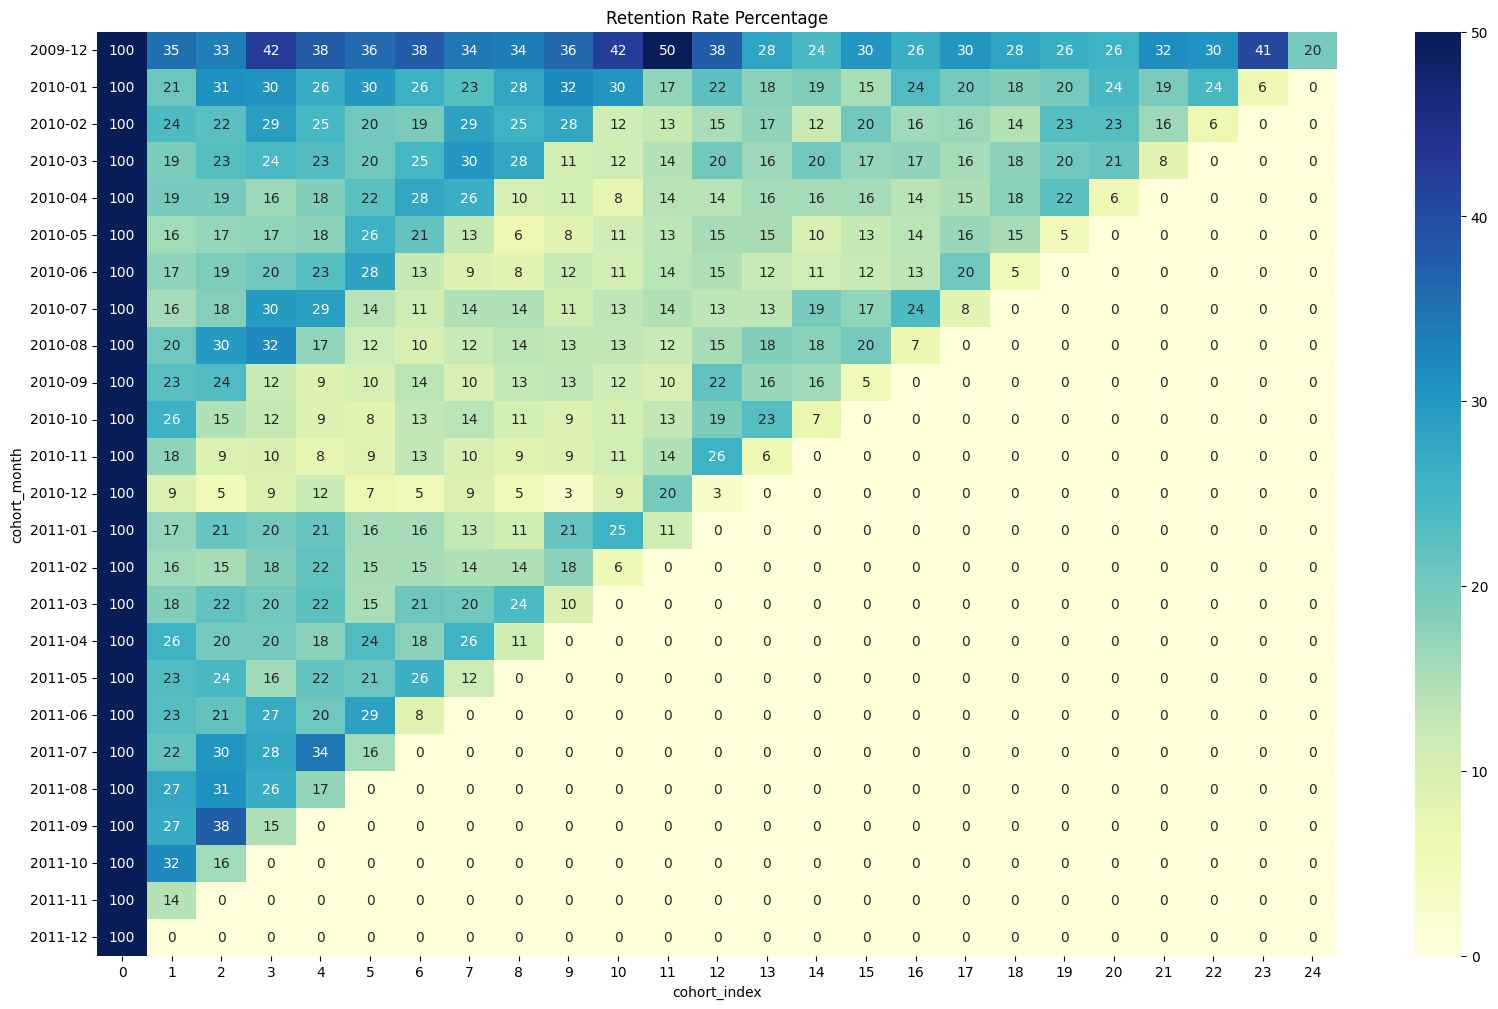

In [9]:
cohort_size=cohots_counts.iloc[:,0]
retention = cohots_counts.divide(cohort_size,axis=0).round(3)*100
retention.index=retention.index.strftime("%Y-%m")
plt.figure(figsize=(20, 12))
plt.title('Retention Rate Percentage')
sns.heatmap(data=retention, 
            annot=True,     # Show the numbers!
            fmt='.0f',      # Round numbers to 0 decimal places
            cmap='YlGnBu',  # Better color contrast (Yellow to Blue)
            vmax=50,        # Caps the color scale at 50% for better contrast
            vmin=0)         # Ensures 0% is the lightest color

plt.show()

- left to right is loyanty or retention
- top to bottom how new customer is adding
- Diagonally occation, chrustmas effect